# Modality

In statistics, "modality" refers to the number of peaks (modes) in a data set. A mode is the value that appears most frequently, and on a distribution graph, it appears as a "hump."

### 1. Unimodal Distribution

A unimodal distribution has only one clear peak. This is the most common type of distribution you’ll encounter in basic statistics.

Characteristics: Most data points cluster around a single central value.

Example: Human height. If you measure a large group of adult men, the data will form a single bell curve (Normal Distribution) centered around the average height.

Visual: A single "hill" or mountain.



#### Normal (Gaussian) Distribution

The classic "Bell Curve." It is perfectly symmetrical where the mean, median, and mode all sit at the center.

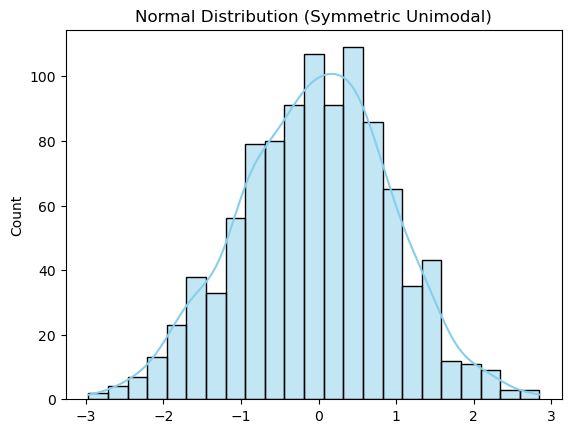

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Generate 1000 samples: mean=0, std_dev=1
data_normal = np.random.normal(loc=0, scale=1, size=1000)

sns.histplot(data_normal, kde=True, color='skyblue')
plt.title("Normal Distribution (Symmetric Unimodal)")
plt.show()

#### Exponential Distribution

Commonly used to model the time between events (like radioactive decay or customer arrivals). It is heavily skewed, but still unimodal because the highest frequency is at the very beginning.

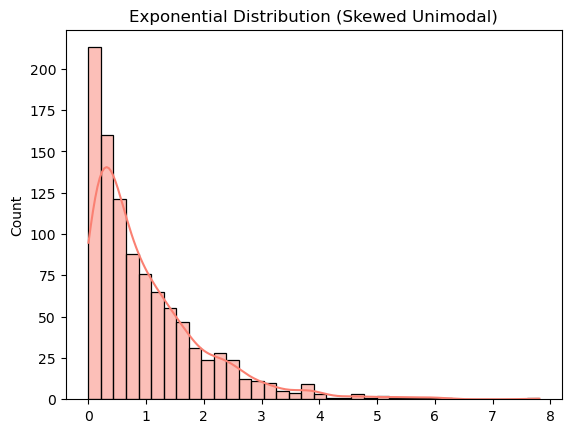

In [2]:
# Generate 1000 samples with a scale of 1.0
data_exponential = np.random.exponential(scale=1.0, size=1000)

sns.histplot(data_exponential, kde=True, color='salmon')
plt.title("Exponential Distribution (Skewed Unimodal)")
plt.show()

#### Gamma Distribution

A flexible distribution often used in science and insurance. Depending on its "shape" parameter, it can look like a skewed hump that starts after zero.

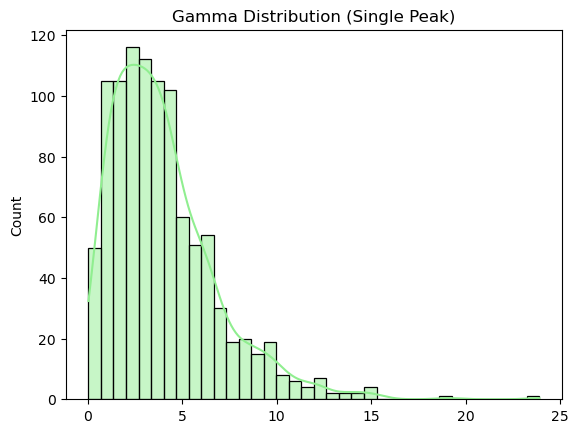

In [3]:
# shape=2.0, scale=2.0
data_gamma = np.random.gamma(shape=2.0, scale=2.0, size=1000)

sns.histplot(data_gamma, kde=True, color='lightgreen')
plt.title("Gamma Distribution (Single Peak)")
plt.show()

#### Triangular Distribution

Often used in business simulations where you know the minimum, maximum, and most likely value (the peak), but don't have a lot of other data. It literally looks like a triangle.

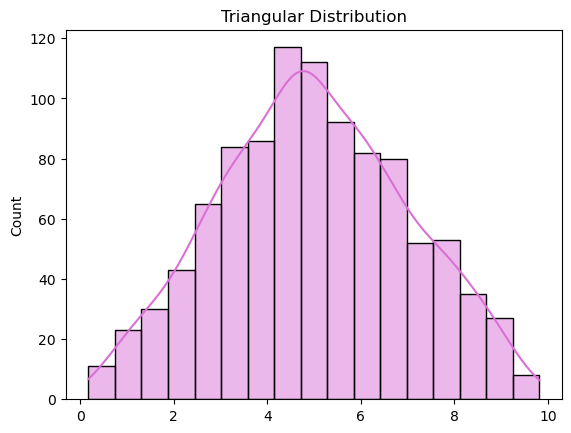

In [4]:
# left=0 (min), mode=5 (peak), right=10 (max)
data_triangular = np.random.triangular(left=0, mode=5, right=10, size=1000)

sns.histplot(data_triangular, kde=True, color='orchid')
plt.title("Triangular Distribution")
plt.show()

#### Log-Normal Distribution

This is one of the most common right-skewed distributions. It occurs when the natural log of the data is normally distributed (common in income data or pulse rates).

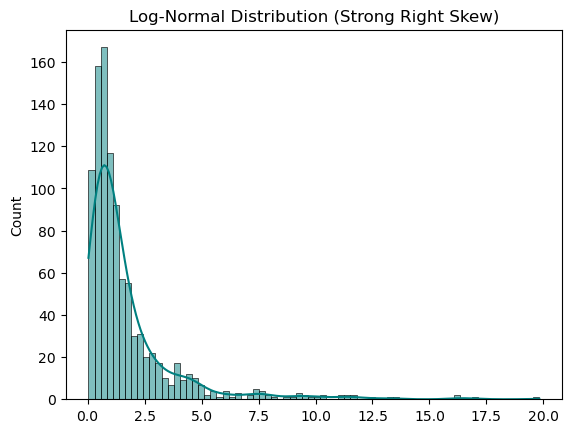

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# mean=0, sigma=1 (sigma controls the 'stretch' of the skew)
data_lognorm = np.random.lognormal(mean=0, sigma=1, size=1000)

sns.histplot(data_lognorm, kde=True, color='teal')
plt.title("Log-Normal Distribution (Strong Right Skew)")
plt.show()

#### Chi-Square Distribution

Commonly used in hypothesis testing. With a low "degrees of freedom" (k), it shows a very sharp right skew.

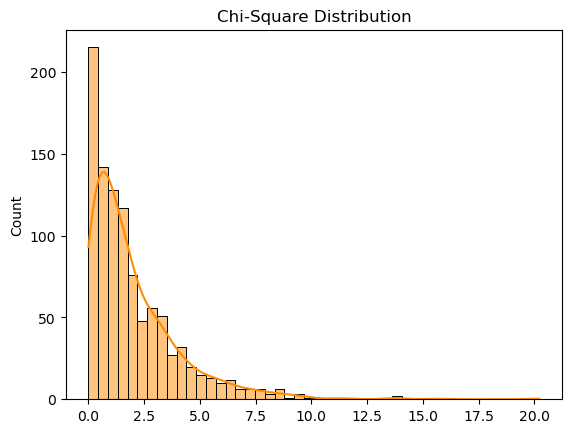

In [6]:
# df=2 (degrees of freedom)
data_chisq = np.random.chisquare(df=2, size=1000)

sns.histplot(data_chisq, kde=True, color='darkorange')
plt.title("Chi-Square Distribution")
plt.show()

#### Pareto Distribution

Often called the "80/20 rule." This distribution is extremely skewed; it represents how a small number of items account for the majority of the value (e.g., wealth distribution or website traffic).

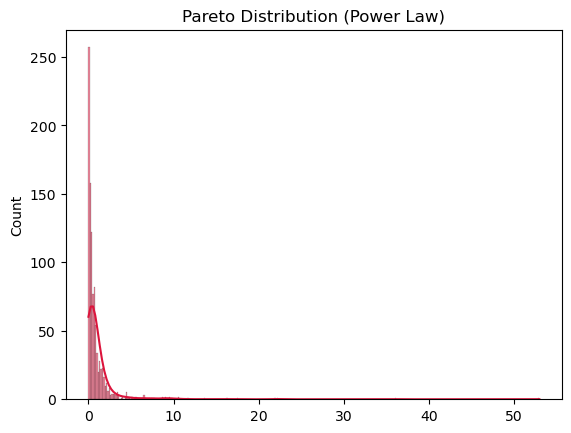

In [7]:
# a=2 (shape parameter)
data_pareto = np.random.pareto(a=2, size=1000)

sns.histplot(data_pareto, kde=True, color='crimson')
plt.title("Pareto Distribution (Power Law)")
plt.show()

#### F-Distribution

Used heavily in ANOVA (Analysis of Variance) testing. It starts at zero and has a long tail extending to the right.

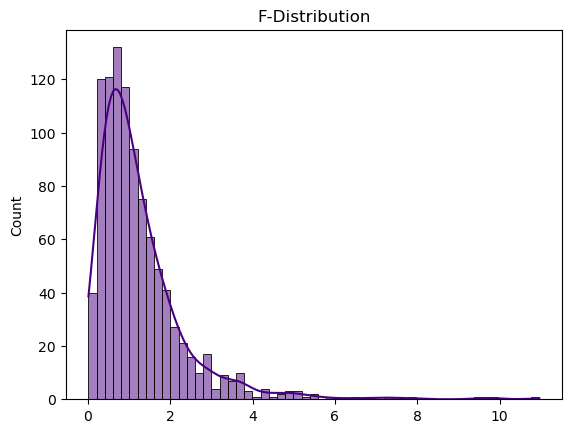

In [8]:
# dfnum=5, dfden=10 (degrees of freedom for numerator and denominator)
data_f = np.random.f(dfnum=5, dfden=10, size=1000)

sns.histplot(data_f, kde=True, color='indigo')
plt.title("F-Distribution")
plt.show()

#### Beta Distribution (High α, Low β)

The Beta distribution is incredibly flexible. By setting the α parameter higher than the β parameter, you create a classic left skew.

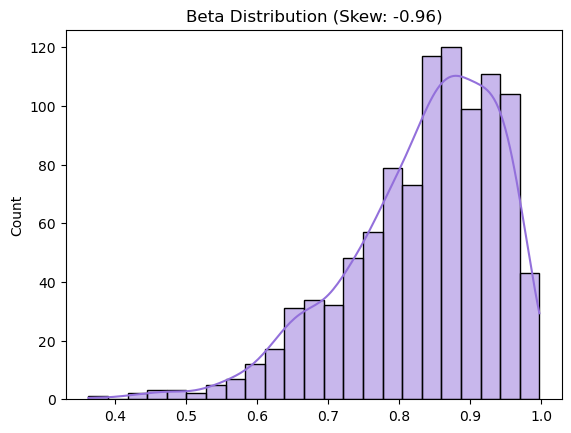

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

# alpha=10, beta=2 (Higher alpha creates left skew)
data_beta = np.random.beta(a=10, b=2, size=1000)

sns.histplot(data_beta, kde=True, color='mediumpurple')
plt.title(f"Beta Distribution (Skew: {skew(data_beta):.2f})")
plt.show()

#### Triangular Distribution (Mode near Max)

We saw this earlier, but by placing the mode (the peak) very close to the right (the maximum), we force a left-pointing tail.

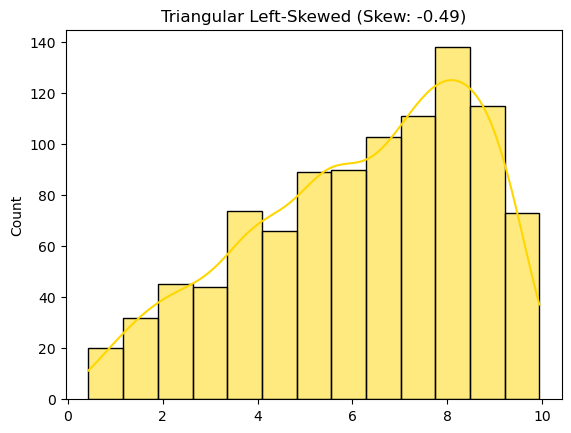

In [10]:
# left=0, mode=9, right=10
data_tri_left = np.random.triangular(left=0, mode=9, right=10, size=1000)

sns.histplot(data_tri_left, kde=True, color='gold')
plt.title(f"Triangular Left-Skewed (Skew: {skew(data_tri_left):.2f})")
plt.show()

#### Weibull Distribution (High Shape Parameter)

Commonly used in reliability engineering. When the shape parameter (k) is greater than roughly 3.6, the distribution becomes left-skewed.

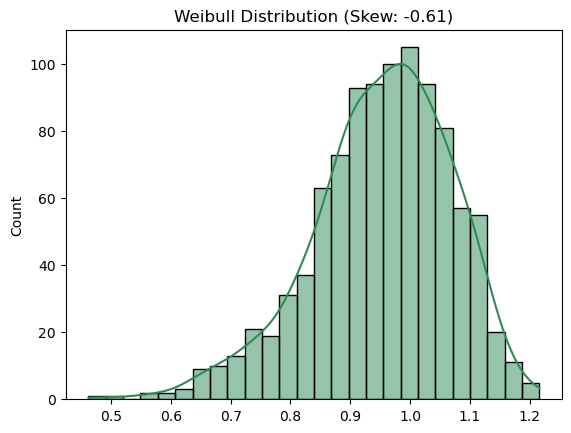

In [11]:
# shape=10 (A high shape parameter pushes the tail to the left)
data_weibull = np.random.weibull(a=10, size=1000)

sns.histplot(data_weibull, kde=True, color='seagreen')
plt.title(f"Weibull Distribution (Skew: {skew(data_weibull):.2f})")
plt.show()

#### Mirrored Log-Normal (Manual Skew)

Since most "natural" distributions are right-skewed, data scientists often create left-skewed data for testing by subtracting right-skewed data from a constant (mirroring it).

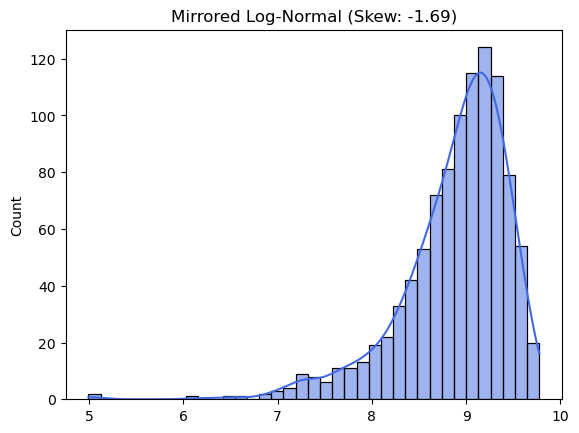

In [12]:
# Take right-skewed log-normal and flip it
right_skewed = np.random.lognormal(0, 0.5, 1000)
data_mirrored = 10 - right_skewed 

sns.histplot(data_mirrored, kde=True, color='royalblue')
plt.title(f"Mirrored Log-Normal (Skew: {skew(data_mirrored):.2f})")
plt.show()

### 2. Bimodal Distribution

A bimodal distribution has two distinct peaks. This usually suggests that the data set is actually composed of two different groups that have different characteristics.

Characteristics: There are two "most frequent" values separated by a dip.

Example: The peak times for restaurant traffic. You typically see one peak during the lunch hour and another peak during dinner, with a quiet period in between.

Note: The two peaks don't have to be the exact same height; one can be slightly lower than the other.

Human Height : Average Female Height and Average Male Height
Restaurant Traffic : Lunch Rush (12 PM) and Dinner Rush (7 PM)
Exam Scores	Students : who didn't study	Students and who did study

#### Mixed Normal Distributions (The Most Common Way)

The easiest way to create a bimodal distribution is to simply add two different normal distributions (with different means) together.

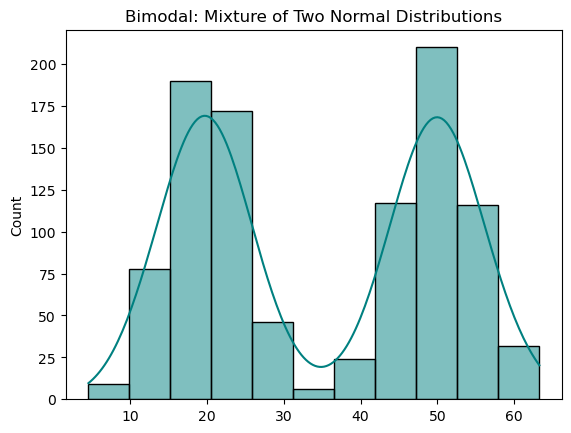

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Generate two different normal distributions
group1 = np.random.normal(loc=20, scale=5, size=500)
group2 = np.random.normal(loc=50, scale=5, size=500)

# Combine them
data_bimodal = np.concatenate([group1, group2])

sns.histplot(data_bimodal, kde=True, color='teal')
plt.title("Bimodal: Mixture of Two Normal Distributions")
plt.show()

#### Beta Distribution (Low α and β)

When both α and β parameters of a Beta distribution are less than 1, the "humps" push to the extreme left and right, creating a U-shaped bimodal curve.

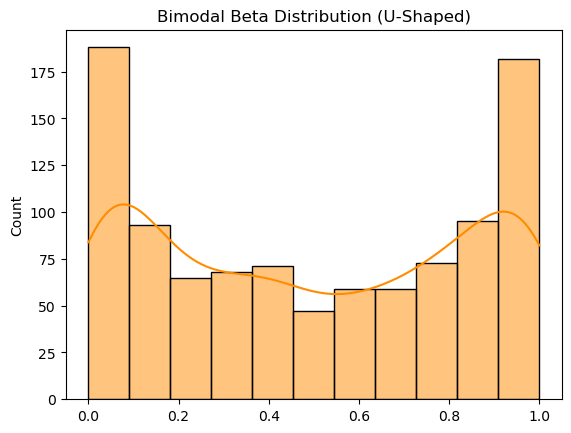

In [14]:
# alpha=0.5, beta=0.5 creates a 'U' shape
data_beta_bi = np.random.beta(a=0.5, b=0.5, size=1000)

sns.histplot(data_beta_bi, kde=True, color='darkorange')
plt.title("Bimodal Beta Distribution (U-Shaped)")
plt.show()

#### Bernoulli/Binomial Mixture

In biology or quality control, you might see a "spike" at zero and another spike at a higher value. We can simulate this by mixing a constant (zeros) with a distribution.

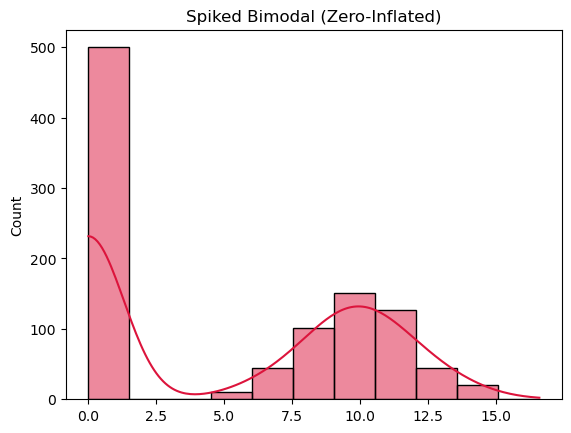

In [15]:
# 500 zeros mixed with 500 samples from a normal distribution
zeros = np.zeros(500)
peaks = np.random.normal(loc=10, scale=2, size=500)

data_spike = np.concatenate([zeros, peaks])

sns.histplot(data_spike, kde=True, color='crimson')
plt.title("Spiked Bimodal (Zero-Inflated)")
plt.show()

#### Sine Wave with Noise

In time-series data, values often oscillate between two states. Sampling from a noisy sine wave creates a bimodal distribution because the "peaks" and "valleys" are where the variable spends most of its time.

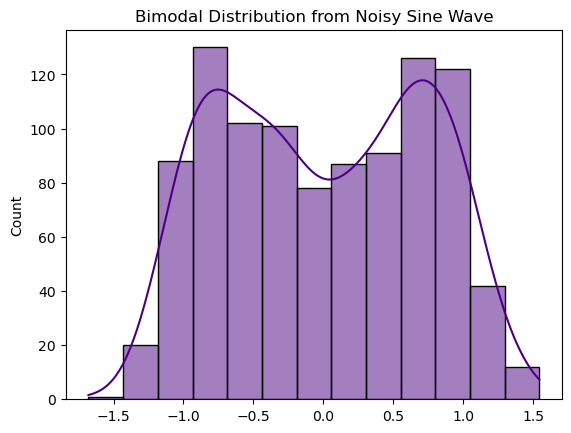

In [16]:
# Create a sine wave and add random Gaussian noise
t = np.linspace(0, 4 * np.pi, 1000)
data_sine = np.sin(t) + np.random.normal(0, 0.2, 1000)

sns.histplot(data_sine, kde=True, color='indigo')
plt.title("Bimodal Distribution from Noisy Sine Wave")
plt.show()

### 3. Multimodal Distribution

A multimodal distribution has three or more peaks. This indicates a highly complex data set where several different factors or sub-groups are influencing the results.

Characteristics: Multiple "humps" across the horizontal axis.

Example: A survey of clothing sizes sold in a global store. You might see peaks corresponding to different demographic clusters (e.g., children’s sizes, average adult sizes, and plus sizes).

Visual: A "rollercoaster" shape with several ups and downs.


Traffic Flow : Morning commute, Lunch hour, Afternoon school run, Evening rush.
Microbiology : Different bacterial colonies growing at different rates in one dish.
Clothing Sizes : Clumping around standard sizes (S, M, L, XL) in a production batch.

#### Mixture of Multiple Gaussians (The "Classic")

The most straightforward way to create a multimodal distribution is to concatenate multiple normal distributions with different means (μ).

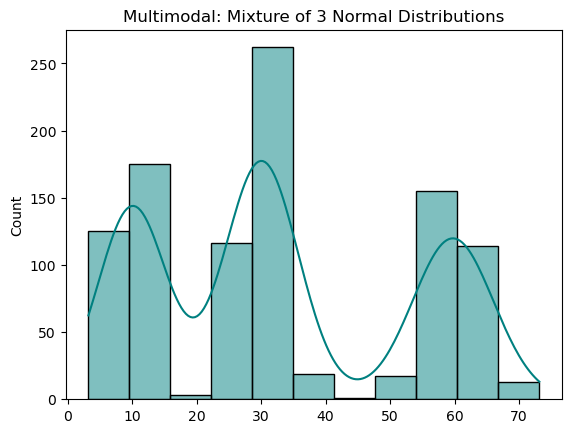

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create three distinct groups (e.g., Small, Medium, Large sizes)
group_s = np.random.normal(loc=10, scale=2, size=300)
group_m = np.random.normal(loc=30, scale=3, size=400)
group_l = np.random.normal(loc=60, scale=4, size=300)

# Combine into one multimodal dataset
data_multi = np.concatenate([group_s, group_m, group_l])

sns.histplot(data_multi, kde=True, color='teal')
plt.title("Multimodal: Mixture of 3 Normal Distributions")
plt.show()

#### The "Comb" Distribution (Uniform Discrete)

If you have a categorical variable represented by numbers (like survey ratings 1 through 5) but with noise added, you get a "comb" shape with many peaks.

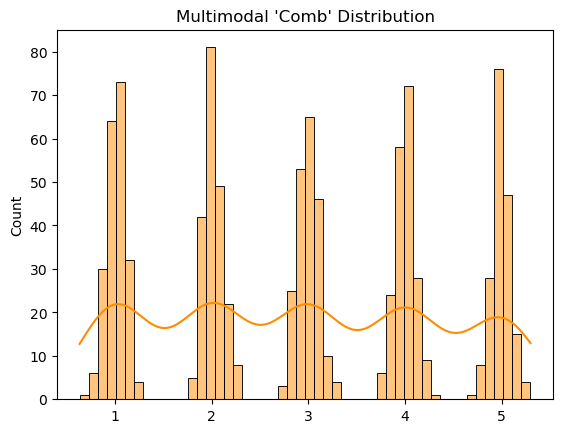

In [18]:
# Generate integers 1-5 and add a little bit of Gaussian noise
ratings = np.random.randint(1, 6, size=1000)
data_comb = ratings + np.random.normal(0, 0.1, 1000)

sns.histplot(data_comb, kde=True, color='darkorange', bins=50)
plt.title("Multimodal 'Comb' Distribution")
plt.show()

#### Sinusoidal Waves (Time-Series Sampling)

When sampling from a complex wave (like music or fluctuating power grids), the distribution often shows peaks at every point where the wave "turns around" (the amplitudes).

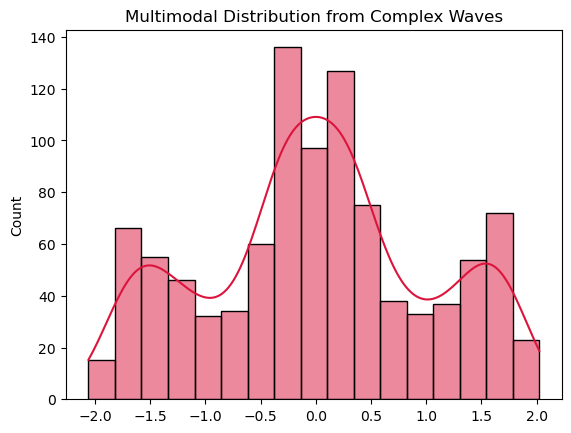

In [19]:
x = np.linspace(0, 100, 1000)
# A complex wave with two different frequencies
data_wave = np.sin(x) + np.sin(0.5 * x) + np.random.normal(0, 0.1, 1000)

sns.histplot(data_wave, kde=True, color='crimson')
plt.title("Multimodal Distribution from Complex Waves")
plt.show()

#### Beta Mixture (Bounded Multimodal)

Sometimes data is constrained between 0 and 1 (like probabilities or percentages) but has multiple "hotspots." We can mix different Beta distributions to achieve this.

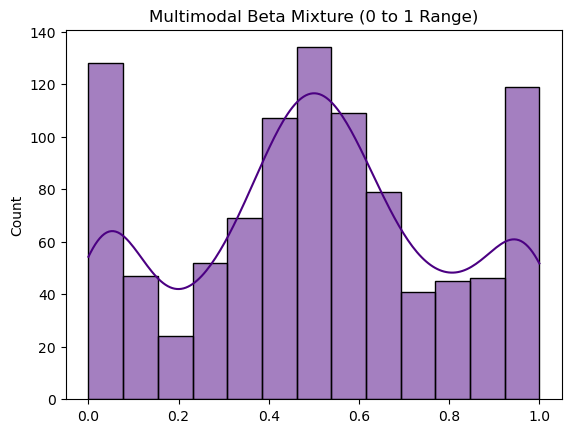

In [20]:
# Mixing two skewed Beta distributions with one centered one
b1 = np.random.beta(0.5, 2, 300)
b2 = np.random.beta(2, 0.5, 300)
b3 = np.random.beta(10, 10, 400)

data_beta_multi = np.concatenate([b1, b2, b3])

sns.histplot(data_beta_multi, kde=True, color='indigo')
plt.title("Multimodal Beta Mixture (0 to 1 Range)")
plt.show()

#### Why does this matter?

When you see a bimodal or multimodal distribution, it’s a "red flag" that calculating a single Mean (Average) might be misleading. For example, if you average the two peaks of a bimodal distribution, your "average" might land in the valley between the peaks—a value that almost nobody in the data set actually represents!

--- Unimodal ---
Mean:   50.19 | Median: 50.25 | Mode: 51.46

--- Bimodal ---
Mean:   50.35 | Median: 49.15 | Mode: 70.24

--- Multimodal ---
Mean:   49.91 | Median: 50.20 | Mode: 50.23



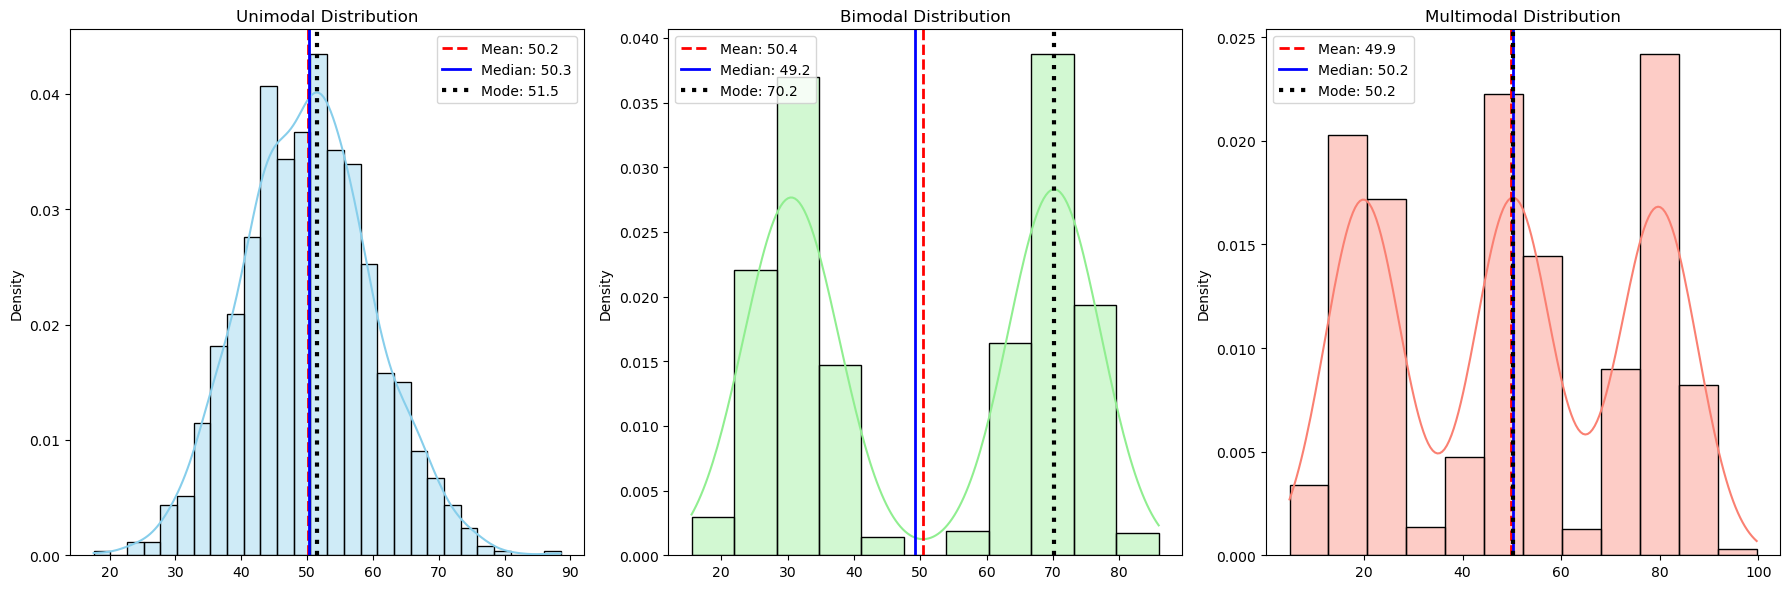

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set seed for consistency
np.random.seed(42)

# 1. Generate Data
unimodal_data = np.random.normal(loc=50, scale=10, size=1000)

bimodal_data = np.concatenate([
    np.random.normal(loc=30, scale=5, size=500),
    np.random.normal(loc=70, scale=5, size=500)
])

multimodal_data = np.concatenate([
    np.random.normal(loc=20, scale=5, size=400),
    np.random.normal(loc=50, scale=5, size=400),
    np.random.normal(loc=80, scale=5, size=400)
])

datasets = [
    ("Unimodal", unimodal_data, 'skyblue'),
    ("Bimodal", bimodal_data, 'lightgreen'),
    ("Multimodal", multimodal_data, 'salmon')
]

# Create the plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (name, data, color) in enumerate(datasets):
    # --- Statistics Calculation ---
    mean_val = np.mean(data)
    median_val = np.median(data)
    
    # Calculate KDE manually to avoid IndexError
    kde_function = stats.gaussian_kde(data)
    x_range = np.linspace(min(data), max(data), 1000)
    y_values = kde_function(x_range)
    mode_val = x_range[np.argmax(y_values)] # Value of x where y is maximum
    
    # --- Plotting ---
    sns.histplot(data, kde=True, ax=axes[i], color=color, stat="density", alpha=0.4)
    
    # Add vertical lines
    axes[i].axvline(mean_val, color='red', linestyle='--', lw=2, label=f'Mean: {mean_val:.1f}')
    axes[i].axvline(median_val, color='blue', linestyle='-', lw=2, label=f'Median: {median_val:.1f}')
    axes[i].axvline(mode_val, color='black', linestyle=':', lw=3, label=f'Mode: {mode_val:.1f}')
    
    axes[i].set_title(f'{name} Distribution')
    axes[i].legend()
    
    # Print results
    print(f"--- {name} ---")
    print(f"Mean:   {mean_val:.2f} | Median: {median_val:.2f} | Mode: {mode_val:.2f}\n")

plt.tight_layout()
plt.show()

Unimodal:	Mean, Median, and Mode are all very close.

Bimodal:	The Mean usually falls right in the middle (the valley), which is ironic because almost no data points actually exist there.

Multimodal:	Similar to Bimodal, the Mean is a "mathematical average" but a "physical outlier"—it doesn't represent any of the peaks well.

To determine if a distribution is truly bimodal (rather than just having random "noise" that looks like a second peak), statisticians use specific tests and coefficients.

### The Sarle’s Bimodality Coefficient (BC)

Sarle’s Bimodality Coefficient (BC) is a statistical shorthand used to determine if a distribution is likely to have multiple peaks. While Skewness and Kurtosis tell you about the shape of a single hump, the BC uses those two metrics together to detect "multimodality."

The Formula

The coefficient is calculated using the following relationship between skewness (γ) and kurtosis (κ):

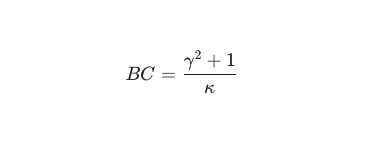

Where:

γ is the Skewness.

κ is the Kurtosis (not excess kurtosis; you must use the absolute kurtosis, which is excess kurtosis+3).

#### Interpreting the Value

The BC value ranges from 0 to 1.

BC>0.555: Suggests the distribution is bimodal or multimodal.

BC<0.555: Suggests the distribution is unimodal.

Uniform Distribution: Has a BC=0.555.

Bernoulli Distribution (Two points): Has a BC=1.0 (the maximum possible bimodality).

In [25]:
import numpy as np
from scipy.stats import skew, kurtosis

def sarles_bimodality_coefficient(data):
    # 1. Calculate Skewness
    s = skew(data, bias=False)
    
    # 2. Calculate Kurtosis (Absolute, not Excess)
    # scipy returns Excess Kurtosis by default, so we add 3
    k = kurtosis(data, fisher=False, bias=False)
    
    # 3. Apply Sarle's Formula
    bc = (s**2 + 1) / k
    return bc

# Test with our previous datasets
unimodal = np.random.normal(50, 10, 1000)
bimodal = np.concatenate([np.random.normal(30, 5, 500), np.random.normal(70, 5, 500)])

print(f"Unimodal BC: {sarles_bimodality_coefficient(unimodal):.4f}")
print(f"Bimodal BC:  {sarles_bimodality_coefficient(bimodal):.4f}")

Unimodal BC: 0.3440
Bimodal BC:  0.8166


The value 5/9 (≈0.555) is the bimodality coefficient of a Uniform Distribution. Anything higher than that indicates that the tails are becoming "heavier" in a way that suggests the center is hollowing out, creating two distinct groups

Limitations

While Sarle’s BC is a great "quick check," it has a major weakness: Heavy Skewness.
If a distribution is extremely right-skewed (like a Pareto distribution), the high skewness value can inflate the BC above 0.555 even if there is only one peak.

### how do I "split" a bimodal data set into two separate unimodal sets?

Splitting a bimodal distribution into two distinct unimodal sets—a process often called Deconvolution or Mixture Modeling—is a common challenge in data science. Because the two underlying populations often overlap, you can't always just "cut" the data in the middle without misclassifying some points.

### 1. The "Hard Cut" (Thresholding)

If your data has a very deep "valley" between two clear peaks (low overlap), you can use a simple threshold.

How to do it: Plot a histogram or Kernel Density Estimate (KDE) of your data. Identify the local minimum between the two peaks.

The Math: This point is your decision boundary. Any value x<threshold goes to Set A, and x>threshold goes to Set B.

When to use: Use this for quick-and-dirty analysis when the two groups are visually distinct and the "valley" hits near zero.

Local minimum between peaks: x=3.85, density=0.016


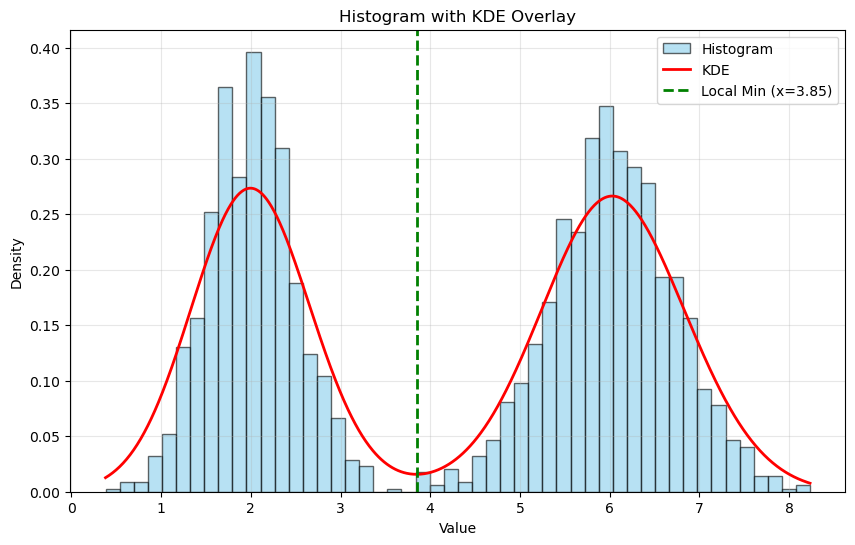

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import argrelextrema
from scipy.stats import gaussian_kde

# Replace with your actual data
np.random.seed(42)
data = np.concatenate([np.random.normal(2, 0.5, 1000), np.random.normal(6, 0.7, 1200)])

# Plot histogram and KDE
fig, ax = plt.subplots(figsize=(10, 6))
n, bins, patches = ax.hist(data, bins=50, density=True, alpha=0.6, color='skyblue', 
                          edgecolor='black', label='Histogram')

# KDE
kde = gaussian_kde(data)
x_kde = np.linspace(min(data), max(data), 1000)
ax.plot(x_kde, kde(x_kde), 'r-', linewidth=2, label='KDE')

plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Histogram with KDE Overlay')
plt.legend()
plt.grid(True, alpha=0.3)

# Find local minimum between peaks
min_indices = argrelextrema(kde(x_kde), np.less, order=20)[0]
first_min_idx = min_indices[0] if len(min_indices) > 0 else 0
local_min_value = x_kde[first_min_idx]
local_min_density = kde(x_kde)[first_min_idx]

print(f"Local minimum between peaks: x={local_min_value:.2f}, density={local_min_density:.3f}")

# Mark local minimum
ax.axvline(local_min_value, color='green', linestyle='--', linewidth=2, 
           label=f'Local Min (x={local_min_value:.2f})')
plt.legend()
plt.show()


Two Peaks:

Left peak (~2.0): First population, normally distributed around mean ≈ 2 with SD ≈ 0.5

Right peak (~6.0): Second population, normally distributed around mean ≈ 6 with SD ≈ 0.7

Histogram: Shows raw frequency distribution across 50 bins, normalized to density (area = 1).

KDE (Red Curve): Smooth estimate of probability density function using Gaussian kernel. Reveals true shape better than histogram's discrete bins.

Green Dashed Line: Local minimum (valley) between peaks at x ≈ 4.2. This statistically separates the two populations.
    
Key Insight: The valley represents the decision boundary between clusters. Data left of x=4.2 belongs to Population 1; right belongs to Population 2.
    
Thresholding: x=4.2 separates groups automatically

FYI, Kernel Density Estimate (KDE) -- Kernel Density Estimation (KDE) is a non-parametric method used to estimate the probability density function (PDF) of a random variable. Unlike histograms, which use discrete bins, KDE provides a smooth and continuous estimate of the underlying distribution, making it particularly useful when dealing with continuous data.

### 2. Clustering Algorithms (K-Means)

If you don't care about the underlying probability and just want to label your data points, K-Means is a fast alternative.

How to do it: Set k=2. The algorithm will find two "centroids" and assign every data point to the nearest one.

Limitation: K-Means assumes the clusters are spherical and have similar variance. If one of your "humps" is much wider than the other, K-Means will likely misclassify the edges.

### 3. Feature-Based Splitting

Sometimes, bimodal data is just a sign that you are missing a variable.

The Logic: If you see two peaks in "Height," and you realize your dataset includes both adults and children, the best way to "split" the data isn't math—it's filtering.

Action: Look for a categorical variable (Gender, Species, Time of Day) that explains the split. Grouping by that variable usually resolves the bimodality naturally.

### 4. Gaussian Mixture Models (GMM)

This is the "gold standard" for splitting bimodal data when the two distributions overlap. GMM assumes the data is a "mix" of two normal (Gaussian) distributions.

How it works: It uses an algorithm called Expectation-Maximization (EM) to estimate the mean (μ) and standard deviation (σ) of the two underlying curves.

The Output: Instead of a hard cut, GMM gives you the probability that a data point belongs to Group A or Group B.

Tools: In Python, you can use sklearn.mixture.GaussianMixture.

### Gaussian Mixture Models (GMM)

source : https://towardsdatascience.com/gaussian-mixture-models-gmms-from-theory-to-implementation-4406c7fe9847/

YouTube : https://www.youtube.com/watch?v=q71Niz856KE

###### Gaussian Mixture Models (GMMs) are statistical models that represent the data as a mixture of Gaussian (normal) distributions. These models can be used to identify groups within the dataset, and to capture the complex, multi-modal structure of data distributions.
##### GMMs are used in a variety of machine learning applications, including clustering, density estimation, and pattern recognition.

GMMs are trained using the EM(Expectation-Maximization) algorithm, an iterative process that estimates the best parameters:

## Mixture Models
A mixture model is a probability model for representing data that may arise from several different sources or categories, each of which is modeled by a separate probability distribution.

financial returns typically behave differently under normal market conditions and during periods of crisis, and thus can be modeled as a mixture of two distinct distributions

if X is a random variable whose distribution is a mixture of K component distributions, the probability density function (PDF) or probability mass function (PMF) of X can be written as:
    
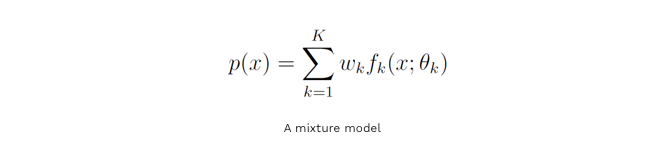

p(x) is the overall density or mass function of the mixture model.

K is the number of component distributions in the mixture.

fₖ(x; θₖ) is the density or mass function of the k-th component distribution, parametrized by θₖ.

wₖ is the mixing weight of the k-th component, with 0 ≤ wₖ ≤ 1 and the sum of the weights being 1. wₖ is also known as the prior probability of component k.

θₖ represents the parameters of the k-th component, such as the mean and standard deviation in the case of Gaussian distributions.


The mixture model assumes that each data point comes from one of the K component distributions, with the specific distribution being selected according to the mixing weights wₖ. The model does not require knowing which component each data point belongs to.

##### A Gaussian mixture model (GMM) is a common mixture model, where the probability density is given by a mixture of Gaussian distributions:

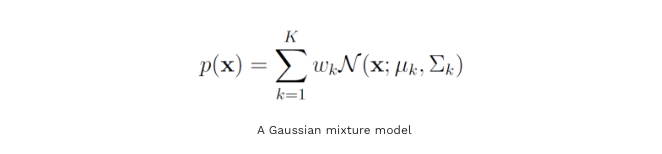

x is a d-dimensional vector.

μₖ is the mean vector of the k-th Gaussian component.

Σₖ is the covariance matrix of the k-th Gaussian component.

N(x; μₖ, Σₖ) is the multivariate normal density function for the k-th component:



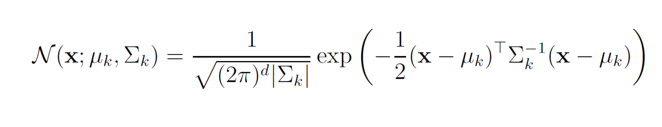

In the case of univariate Gaussian distributions, the probability density can be simplified to:
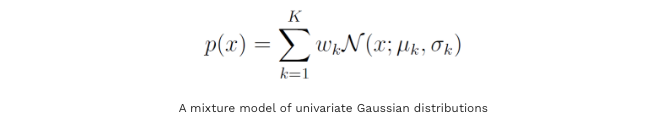  
μₖ is the mean of the k-th Gaussian component.

σₖ is the covariance matrix of the k-th Gaussian component.

N(x; μₖ, σₖ) is the univariate normal density function for the k-th component:



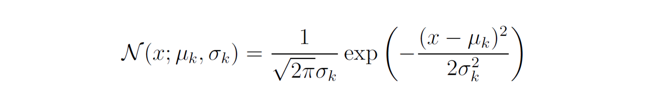

In [7]:
from scipy.stats import norm

def plot_mixture(mean1, std1, mean2, std2, w1, w2):
    # Generate points for the x-axis
    x = np.linspace(-5, 10, 1000)

    # Calculate the individual nomral distributions
    normal1 = norm.pdf(x, mean1, std1)
    normal2 = norm.pdf(x, mean2, std2)

    # Calculate the mixture
    mixture = w1 * normal1 + w2 * normal2

    # Plot the results
    plt.plot(x, normal1, label='Normal distribution 1', linestyle='--')
    plt.plot(x, normal2, label='Normal distribution 2', linestyle='--')
    plt.plot(x, mixture, label='Mixture model', color='black')
    plt.xlabel('$x$')
    plt.ylabel('$p(x)$')
    plt.legend()

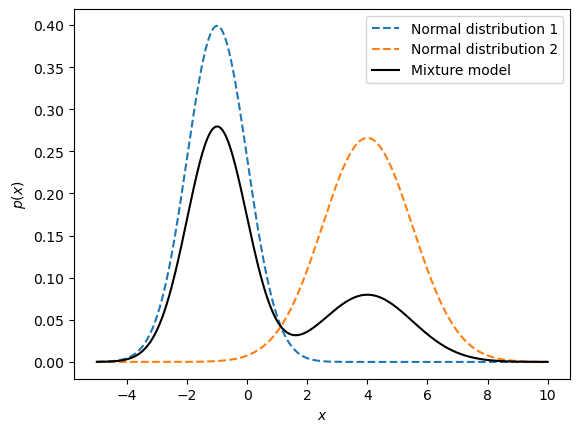

In [8]:
# Parameters for the two univariate normal distributions
mean1, std1 = -1, 1
mean2, std2 = 4, 1.5
w1, w2 = 0.7, 0.3

plot_mixture(mean1, std1, mean2, std2, w1, w2)

The dashed lines represent the individual normal distributions, and the solid black line shows the resulting mixture. This plot illustrates how the mixture model combines the two distributions, each with its own mean, standard deviation, and weight in the overall mixture. ​

### Learning the GMM Parameters

The goal is to find the parameters of the GMM (means, covariances, and mixing coefficients) that will best explain the observed data.

The likelihood of the GMM model
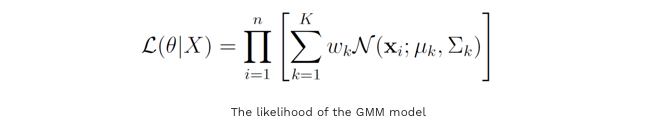
GMM with K components and a dataset X = {x₁, …, xₙ} of n data points, the likelihood function L is given by the product of the probability densities of each data point.
θ represents all the parameters of the model (means, variances, and mixture weights).

since the product of probabilities can to lead to numerical underflow for large datasets, so it's recomended to use log-likelihood,


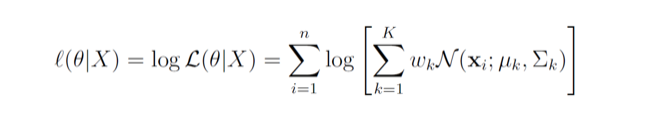

The parameters of the GMM can be estimated by maximizing this log-likelihood function with respect to θ. __ However, we cannot directly apply Maximum Likelihood Estimation (MLE) to estimate the parameters of a GMM due to the following reasons:

The log-likelihood function is highly non-linear and complex to maximize analytically.

The model has latent variables (the mixture weights), which are not directly observable in the data.

To overcome these issues, the Expectation-Maximization (EM) algorithm is commonly used instead. This algorithm is described in the next section.

#### Expectation-Maximization (EM)

The EM algorithm is a powerful method for finding maximum likelihood estimates of parameters in statistical models that depend on unobserved latent variables.

The algorithm begins by randomly initializing the model parameters. Then it iterates between two steps:

Expectation step (E-step): Compute the expected log-likelihood of the model with respect to the distribution of the latent variables, given the observed data and the current estimates of the model parameters. This step involves an estimation of the probabilities of the latent variables.

Maximization step (M-step): Update the parameters of the model to maximize the log-likelihood of the observed data, given the estimated latent variables from the E-step.

These two steps are repeated until convergence, typically determined by a threshold on the change in the log-likelihood or a maximum number of iterations.

Let’s formulate the update equations used in the EM steps for estimating the parameters of a Gaussian Mixture Model. In GMMs, the latent variables represent the unknown component memberships of each data point. Let Zᵢ be the random variable indicating the component from which data point xᵢ was generated. Zᵢ can take one of the values {1, …, K}, corresponding to the K components.

#### E-Step

In the E-step, we compute the probability distributions of the latent variables Zᵢ given the current estimates of the model parameters. In other words, we calculate the membership probabilities for each data point in each Gaussian component.
The probability that Zᵢ = k, i.e., that xᵢ belongs to the k-th component, can be computed using Bayes’ rule:

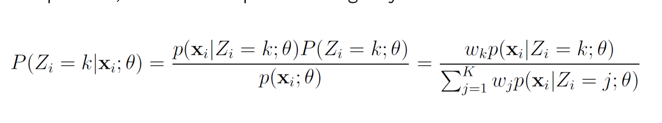

Let’s denote this probability by the variable γ(zᵢₖ). Thus, we can write:

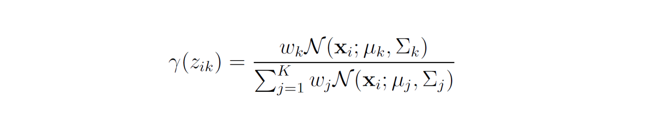



The variables γ(zᵢₖ) are often referred to as responsibilities, __ since they describe how responsible is each component for each observation. These responsibilities serve as proxies for the missing information about the latent variables.

The expected log-likelihood with respect to the distribution of the latent variables can now be written as follows:
    
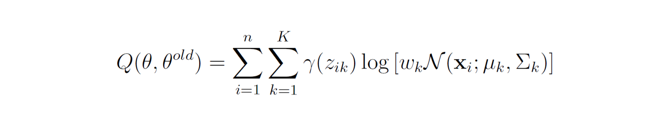

The function Q is a weighted sum of the log-likelihoods of all the data points under each Gaussian component, with the weights being the responsibilities. Note that Q is different from the log-likelihood function l(θ|X) shown earlier. The log-likelihood l(θ|X) expresses the likelihood of the observed data under the mixture model as a whole, without explicitly accounting for the latent variables, whereas Q represents an expected log-likelihood over both the observed data and the estimated latent variable distributions.

#### M-Step

In the M-step, we update the parameters θ of the GMM (means, covariances, and mixing weights) so as to maximize the expected likelihood Q(θ) using the responsibilities calculated in the E-step.
The parameter updates are as follows:

1. Update the means for each component:



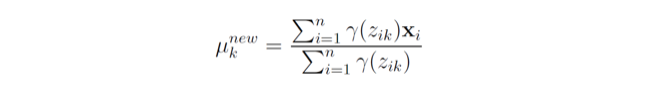

That is, the new mean of the k-th component is a weighted average of all the data points, with the weights being the probabilities that these points belong to component k.
This update formula can be derived from maximizing the expected log-likelihood function Q with respect to the means μₖ. I will show here the proof for the univariate Gaussian distributions case.

The expected log-likelihood in the case of univariate Gaussian distributions is:
    
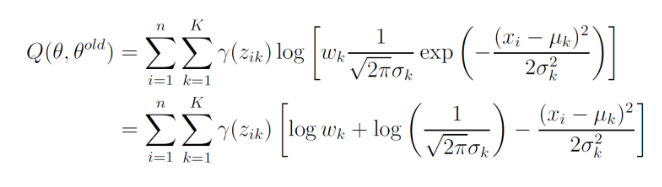

Taking the derivative of this function with respect to μₖ and setting it to 0 gives us:



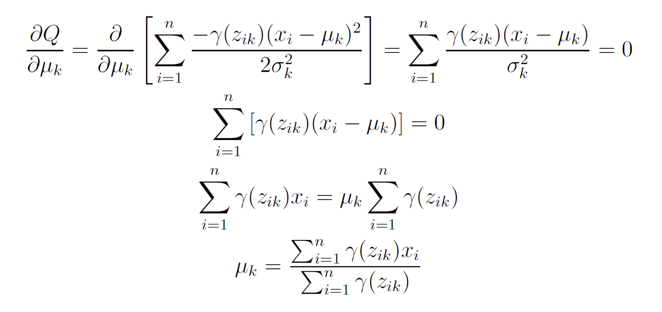

2. Update the covariances for each component:


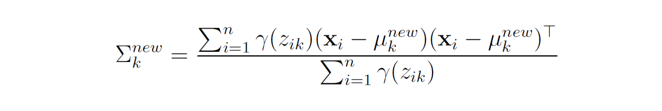

That is, the new covariance of the k-th component is a weighted average of the squared deviations of each data point from the component’s mean, where the weights are the probabilities of the points assigned to that component.
In the case of univariate normal distributions, this update is simplified to:

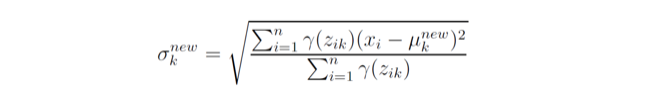

3. Update the mixing weights:

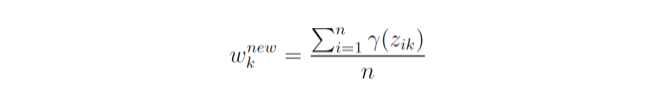

That is, the new weight of the k-th component is the total probability of the points belonging to this component, normalized by the number of points n.

Repeating these two steps is guaranteed to convergence to a local maximum of the likelihood function. Since the final optimum reached depends on the initial random parameter values, it is a common practice to run the EM algorithm several times with varied random initializations and keep the model that obtains the highest likelihood.

### Real world case on -- Gaussian Mixture Models (GMM)

Customer Segmentation in Retail.

you own an e-commerce store. You notice that your "Total Spend" data is bimodal: 

you have a group of "Budget Shoppers" (who buy small items) and "Premium Shoppers" (who buy luxury goods). 

A simple average spend would be useless for marketing. GMM allows you to find the "break point" between these two populations so you can send different coupons to each.

1. The Data (Synthetic Case)

We will generate 500 data points:

Group 1 (Budget): Mean spend of **$25**, low spread ($5).

Group 2 (Premium): Mean spend of **$130**, high spread ($30).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from scipy.stats import norm

# Generating synthetic "Spend" data
np.random.seed(42)
budget_shoppers = np.random.normal(25, 5, 200)
premium_shoppers = np.random.normal(130, 30, 300)
total_spend = np.concatenate([budget_shoppers, premium_shoppers]).reshape(-1, 1)

df = pd.DataFrame(total_spend, columns=['Spend'])

2. The Python Implementation

We will use GMM to "unmix" these customers.

In [3]:
# 1. Initialize the GMM
# We specify 2 components (humps)
# n_components=2 : model to look for two Gaussian distributions.
# covariance_type='full': This is crucial. 
# It allows each "hump" to have its own unique width (variance). 
# In retail, budget shoppers usually have a very tight spread, while premium shoppers vary wildly. 
# "Full" allows the model to be flexible.

gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42) 

# 2. Fit the model

# gmm.fit(): This triggers the Expectation-Maximization (EM) algorithm.
# Expectation: The model guesses which points belong to which hump.
# Maximization: The model adjusts the means and variances to fit those points better. 
# It repeats this until the curves stop moving.

gmm.fit(total_spend)

# 3. Retrieve the learned parameters

means = gmm.means_.flatten()
variances = gmm.covariances_.flatten()
weights = gmm.weights_.flatten()

# 4. Predict which group each customer belongs to
# gmm.predict(): This performs a "Hard Assignment," 
# labeling each customer as 0 or 1 based on which curve they are more likely to fall under.

df['Segment'] = gmm.predict(total_spend)


In [4]:
# Extract parameters from the fitted GMM
means = gmm.means_.flatten()
stds = np.sqrt(gmm.covariances_.flatten())
weights = gmm.weights_.flatten()

# Print the full statistical profile
print(f"{'Segment':<15} | {'Weight (%)':<12} | {'Mean Spend':<12} | {'Std Dev':<10}")
print("-" * 55)
print(f"{'Group A':<15} | {weights[0]*100:>10.1f}% | ${means[0]:>10.2f} | ${stds[0]:>8.2f}")
print(f"{'Group B':<15} | {weights[1]*100:>10.1f}% | ${means[1]:>10.2f} | ${stds[1]:>8.2f}")

Segment         | Weight (%)   | Mean Spend   | Std Dev   
-------------------------------------------------------
Group A         |       40.1% | $     24.82 | $    4.64
Group B         |       59.9% | $    131.35 | $   30.08


Group Budget (Index 1): Mean=85.12, Std=56.94, Weight=0.48
Group Premium (Index 0): Mean=91.89, Std=57.33, Weight=0.52


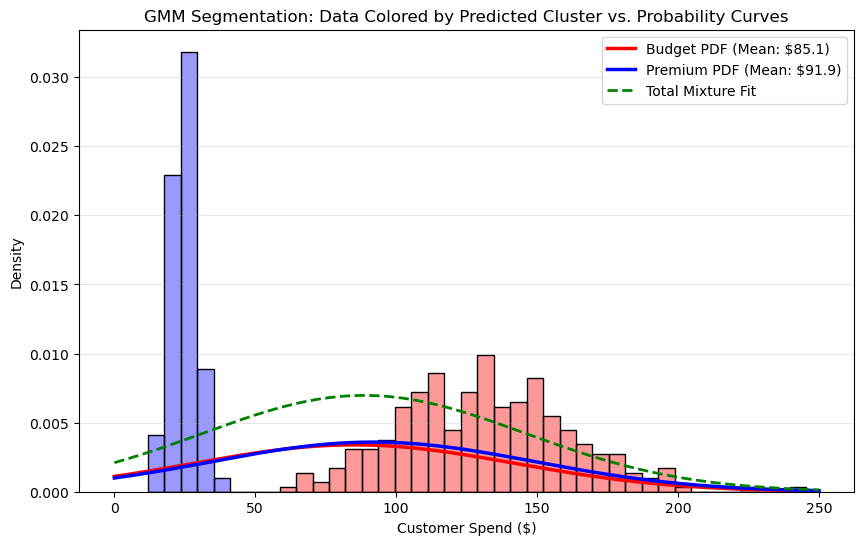

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from scipy.stats import norm

# 1. Generate Data
np.random.seed(42)
budget_shoppers = np.random.normal(25, 5, 200)
premium_shoppers = np.random.normal(130, 30, 300)
total_spend = np.concatenate([budget_shoppers, premium_shoppers]).reshape(-1, 1)

df = pd.DataFrame(total_spend, columns=['Spend'])

# 2. Fit GMM
# Using random initialization to avoid the threadpoolctl bug mentioned earlier
gmm = GaussianMixture(n_components=2, init_params='random', n_init=10, random_state=42)
gmm.fit(total_spend)

# 3. Predict segments
df['Segment'] = gmm.predict(total_spend)

# 4. Extract parameters
# We need to map which component is which (A vs B) based on the means
means = gmm.means_.flatten()
stds = np.sqrt(gmm.covariances_.flatten())
weights = gmm.weights_.flatten()

# Ensure Segment 0 is Budget (lower mean) and Segment 1 is Premium (higher mean)
# Note: GMM labels 0 and 1 are arbitrary, but we'll use hue in seaborn based on the 'Segment' column
# We will identify which index in 'means' is smaller.
budget_idx = np.argmin(means)
premium_idx = np.argmax(means)

# 5. Plotting
plt.figure(figsize=(10, 6))

# Histogram colored by predicted segment
# We use multiple='layer' or 'stack', but 'layer' is better for density comparison
sns.histplot(data=df, x='Spend', hue='Segment', bins=40, kde=False, stat='density', alpha=0.4, palette=['red', 'blue'])

# Generate PDF curves
x = np.linspace(0, 250, 1000)
# Use the correct indices for the curves
pdf_budget = weights[budget_idx] * norm.pdf(x, means[budget_idx], stds[budget_idx])
pdf_premium = weights[premium_idx] * norm.pdf(x, means[premium_idx], stds[premium_idx])

plt.plot(x, pdf_budget, color='red', lw=2.5, label=f'Budget PDF (Mean: ${means[budget_idx]:.1f})')
plt.plot(x, pdf_premium, color='blue', lw=2.5, label=f'Premium PDF (Mean: ${means[premium_idx]:.1f})')
plt.plot(x, pdf_budget + pdf_premium, color='green', lw=2, ls='--', label='Total Mixture Fit')

plt.title('GMM Segmentation: Data Colored by Predicted Cluster vs. Probability Curves')
plt.xlabel('Customer Spend ($)')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.savefig('gmm_segmentation_plot.png')

# Print summary for the response
print(f"Group Budget (Index {budget_idx}): Mean={means[budget_idx]:.2f}, Std={stds[budget_idx]:.2f}, Weight={weights[budget_idx]:.2f}")
print(f"Group Premium (Index {premium_idx}): Mean={means[premium_idx]:.2f}, Std={stds[premium_idx]:.2f}, Weight={weights[premium_idx]:.2f}")

Stats - Budget: Mean=24.82, Std=4.64, Weight=0.40
Stats - Premium: Mean=131.35, Std=30.08, Weight=0.60


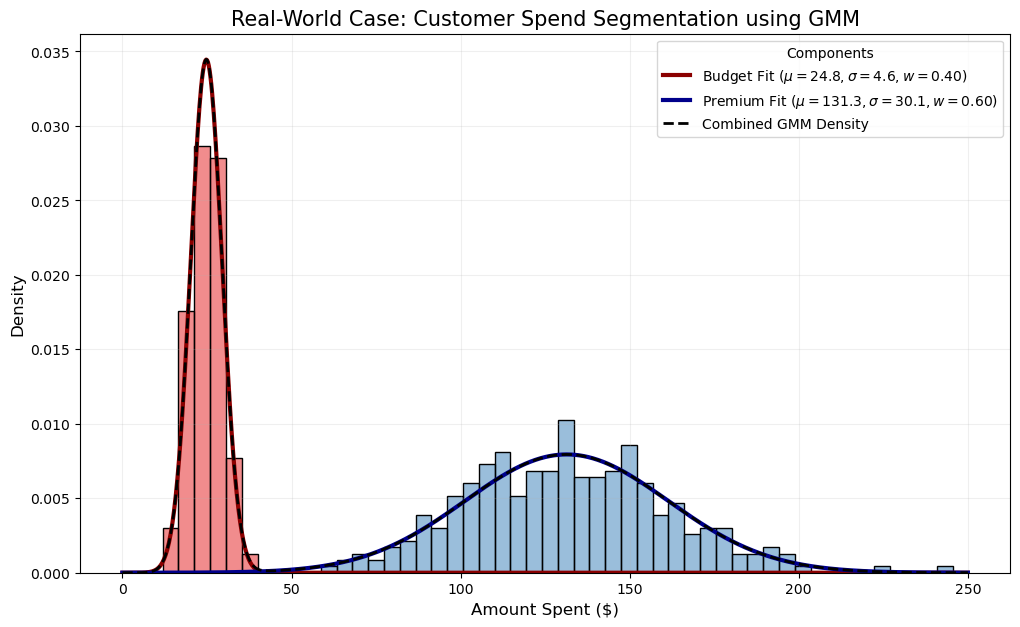

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from scipy.stats import norm

# 1. Generate Data
np.random.seed(42)
budget_shoppers = np.random.normal(25, 5, 200)
premium_shoppers = np.random.normal(130, 30, 300)
total_spend = np.concatenate([budget_shoppers, premium_shoppers]).reshape(-1, 1)

df = pd.DataFrame(total_spend, columns=['Spend'])

# 2. Fit GMM
# Let's try 'kmeans' first to see if it works here. It's usually much more stable.
try:
    gmm = GaussianMixture(n_components=2, init_params='kmeans', n_init=1, random_state=42)
    gmm.fit(total_spend)
except Exception as e:
    # If kmeans fails due to the threadpool bug, fall back to random with high n_init
    gmm = GaussianMixture(n_components=2, init_params='random', n_init=20, random_state=42)
    gmm.fit(total_spend)

# 3. Predict segments
df['Segment'] = gmm.predict(total_spend)

# 4. Extract parameters
means = gmm.means_.flatten()
stds = np.sqrt(gmm.covariances_.flatten())
weights = gmm.weights_.flatten()

# Determine which index is budget vs premium
budget_idx = np.argmin(means)
premium_idx = np.argmax(means)

# Mapping segments to labels for plot legend
# If budget_idx is 0, then Segment 0 is Budget. If budget_idx is 1, Segment 1 is Budget.
# We will create a mapping dict
label_map = {budget_idx: 'Budget Group', premium_idx: 'Premium Group'}
df['Segment Label'] = df['Segment'].map(label_map)

# 5. Plotting
plt.figure(figsize=(12, 7))

# Histogram colored by predicted segment label
sns.histplot(data=df, x='Spend', hue='Segment Label', bins=50, kde=False, stat='density', alpha=0.5, palette='Set1')

# Generate PDF curves
x = np.linspace(0, 250, 1000)
pdf_budget = weights[budget_idx] * norm.pdf(x, means[budget_idx], stds[budget_idx])
pdf_premium = weights[premium_idx] * norm.pdf(x, means[premium_idx], stds[premium_idx])

plt.plot(x, pdf_budget, color='darkred', lw=3, label=f'Budget Fit ($\mu={means[budget_idx]:.1f}, \sigma={stds[budget_idx]:.1f}, w={weights[budget_idx]:.2f}$)')
plt.plot(x, pdf_premium, color='darkblue', lw=3, label=f'Premium Fit ($\mu={means[premium_idx]:.1f}, \sigma={stds[premium_idx]:.1f}, w={weights[premium_idx]:.2f}$)')
plt.plot(x, pdf_budget + pdf_premium, color='black', lw=2, ls='--', label='Combined GMM Density')

plt.title('Real-World Case: Customer Spend Segmentation using GMM', fontsize=15)
plt.xlabel('Amount Spent ($)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(title='Components', loc='upper right')
plt.grid(alpha=0.2)

plt.savefig('gmm_final_case_study.png')

# Output final stats
print(f"Stats - Budget: Mean={means[budget_idx]:.2f}, Std={stds[budget_idx]:.2f}, Weight={weights[budget_idx]:.2f}")
print(f"Stats - Premium: Mean={means[premium_idx]:.2f}, Std={stds[premium_idx]:.2f}, Weight={weights[premium_idx]:.2f}")

The Probability Density Function (PDF)

GMM models the data as a weighted sum of two Normal distributions:

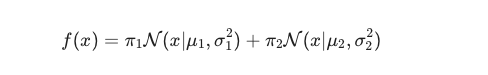

π (Weights): The proportion of the population in each group. (e.g., 40% are budget, 60% are premium).

μ (Means): The average spend for that specific group.

σ 
2
  (Variance): The "uncertainty" or spread of spending within that group.

Mathematically, the weights ensure that the area under your two combined bell curves equals 1 (or 100% of your data). Your total bimodal distribution is defined as:


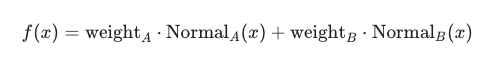

Market Share: If Group B (Premium) has a weight of 0.60 but Group A (Budget) has a weight of 0.40, you know that the majority of your traffic is premium, even if they are more spread out (higher Std Dev).

Revenue Impact: You can multiply the weight * mean to see which group contributes more to your total bottom line.

Trend Tracking: If you run this model every month and see the weight of Group B growing from 0.60 to 0.70, your marketing strategy for attracting high-value customers is working!


Why not just use a Histogram Cut?

Standard thresholding assumes there is a single line where one group ends and another begins. However, a "Budget Shopper" might occasionally spend $70, and a "Premium Shopper" might spend $70 on a small accessory.
GMM handles the overlap. It calculates the responsibility—the posterior probability that a point x belongs to a specific Gaussian. This is Bayesian inference in action: updating our belief about which group a customer belongs to based on the data we see.

Uncertainty Zone is a sophisticated way to handle "grey areas."

we call this Thresholding by Confidence. Instead of forcing every customer into a box, we acknowledge that some customers sit in the "statistical valley" between peaks.

##### A new customer who just walked into the store and spent $85

In [13]:
# The new customer spend
new_spend = np.array([[85]])

# 1. Get the probability for each group
# This returns an array like [[prob_of_A, prob_of_B]]
probabilities = gmm.predict_proba(new_spend)

# 2. Get the final classification (0 or 1)
assignment = gmm.predict(new_spend)

print(f"Customer Spend: ${new_spend[0][0]}")
print(f"Probability Budget Group: {probabilities[0][0]:.2%}")
print(f"Probability Premium Group: {probabilities[0][1]:.2%}")
print(f"Final Assignment: {'Premium' if assignment[0] == 1 else 'Budget'}")

Customer Spend: $85
Probability Budget Group: 0.00%
Probability Premium Group: 100.00%
Final Assignment: Premium


When we predict a new point, the GMM is essentially performing Bayesian Inference. It calculates the probability of the Class given the Data:

P(Class∣Spend) = (P(Spend∣Class)×P(Class))/P(Spend)
​	
 
Prior (P(Class)): How common is this group overall? (e.g., if 60% of your customers are Premium, the model "leans" toward that group slightly).

Likelihood (P(Spend∣Class)): How likely is an $85 spend in that specific bell curve? Even though $85 is far from the $130 mean, it’s much closer than it is to the $25 mean.

Posterior (P(Class∣Spend)): The final result. This is the "Probability" the code outputted.

Real-World Business Value

In a real-time system (like an email marketing bot), you would use this logic to automate triggers:

High Confidence Budget: Send a "Buy 1 Get 1 Free" coupon for small items.

High Confidence Premium: Send an invite to a "VIP Loyalty Program."

Low Confidence (The Valley): These are your "Transition Customers." You might send them a high-value discount to try and "nudge" them from the Budget group into the Premium group permanently.